In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better visualization
sns.set(style="whitegrid")
print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:
df = pd.read_csv("al-qaida_all_prn_legacy.csv")
df.shape
# df.head()

(255, 288)

In [13]:
df.columns

Index(['DATAID', 'VERSIONNUM', 'FIRST_NAME', 'SECOND_NAME', 'THIRD_NAME',
       'FOURTH_NAME', 'UN_LIST_TYPE', 'REFERENCE_NUMBER', 'LISTED_ON',
       'NAME_ORIGINAL_SCRIPT',
       ...
       'INDIVIDUAL_ALIAS/12/NOTE', 'INDIVIDUAL_ALIAS/13/NOTE',
       'INDIVIDUAL_ALIAS/9/NOTE', 'INDIVIDUAL_PLACE_OF_BIRTH/2/CITY',
       'INDIVIDUAL_PLACE_OF_BIRTH/2/STATE_PROVINCE',
       'INDIVIDUAL_PLACE_OF_BIRTH/2/COUNTRY', 'INDIVIDUAL_ADDRESS/3/STREET',
       'INDIVIDUAL_ADDRESS/3/STATE_PROVINCE',
       'INDIVIDUAL_DOCUMENT/4/TYPE_OF_DOCUMENT2',
       'INDIVIDUAL_DOCUMENT/4/NOTE'],
      dtype='str', length=288)

In [11]:
df.head()

,DATAID,VERSIONNUM,FIRST_NAME,SECOND_NAME,THIRD_NAME,FOURTH_NAME,UN_LIST_TYPE,REFERENCE_NUMBER,LISTED_ON,NAME_ORIGINAL_SCRIPT,...,INDIVIDUAL_ALIAS/12/NOTE,INDIVIDUAL_ALIAS/13/NOTE,INDIVIDUAL_ALIAS/9/NOTE,INDIVIDUAL_PLACE_OF_BIRTH/2/CITY,INDIVIDUAL_PLACE_OF_BIRTH/2/STATE_PROVINCE,INDIVIDUAL_PLACE_OF_BIRTH/2/COUNTRY,INDIVIDUAL_ADDRESS/3/STREET,INDIVIDUAL_ADDRESS/3/STATE_PROVINCE,INDIVIDUAL_DOCUMENT/4/TYPE_OF_DOCUMENT2,INDIVIDUAL_DOCUMENT/4/NOTE
0,113219,1,MOHAMMED,SALAHALDIN,ABD EL HALIM,ZIDANE,Al-Qaida,QDi.001,2001-01-25,محمد صلاح الدين عبدالحليم زيدان,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,111497,1,AMIN,MUHAMMAD,UL HAQ,SAAM KHAN,Al-Qaida,QDi.002,2001-01-25,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,111919,1,SALIM,AHMAD,SALIM,HAMDAN,Al-Qaida,QDi.003,2001-01-25,سالم أحمد سالم حمدان,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,111923,1,AIMAN,MUHAMMED,RABI,AL-ZAWAHIRI,Al-Qaida,QDi.006,2001-01-25,أيمن محمد ربيع الظواهري,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,111942,1,BILAL,BIN MARWAN,NaN,NaN,Al-Qaida,QDi.009,2001-01-25,بلال بن مروان,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Columns: 288 entries, DATAID to INDIVIDUAL_DOCUMENT/4/NOTE
dtypes: float64(17), int64(2), str(269)
memory usage: 573.9 KB


In [15]:
df.isnull().sum()

DATAID                                       0
VERSIONNUM                                   0
FIRST_NAME                                   0
SECOND_NAME                                  2
THIRD_NAME                                  91
                                          ... 
INDIVIDUAL_PLACE_OF_BIRTH/2/COUNTRY        253
INDIVIDUAL_ADDRESS/3/STREET                254
INDIVIDUAL_ADDRESS/3/STATE_PROVINCE        254
INDIVIDUAL_DOCUMENT/4/TYPE_OF_DOCUMENT2    254
INDIVIDUAL_DOCUMENT/4/NOTE                 254
Length: 288, dtype: int64

In [5]:
df.columns

Index(['DATAID', 'VERSIONNUM', 'FIRST_NAME', 'SECOND_NAME', 'THIRD_NAME',
       'FOURTH_NAME', 'UN_LIST_TYPE', 'REFERENCE_NUMBER', 'LISTED_ON',
       'NAME_ORIGINAL_SCRIPT',
       ...
       'INDIVIDUAL_ALIAS/12/NOTE', 'INDIVIDUAL_ALIAS/13/NOTE',
       'INDIVIDUAL_ALIAS/9/NOTE', 'INDIVIDUAL_PLACE_OF_BIRTH/2/CITY',
       'INDIVIDUAL_PLACE_OF_BIRTH/2/STATE_PROVINCE',
       'INDIVIDUAL_PLACE_OF_BIRTH/2/COUNTRY', 'INDIVIDUAL_ADDRESS/3/STREET',
       'INDIVIDUAL_ADDRESS/3/STATE_PROVINCE',
       'INDIVIDUAL_DOCUMENT/4/TYPE_OF_DOCUMENT2',
       'INDIVIDUAL_DOCUMENT/4/NOTE'],
      dtype='str', length=288)

In [7]:
# 1. Clean column names
df.columns = df.columns.str.lower().str.replace('/', '_').str.replace(' ', '_')

In [8]:
df.columns


Index(['dataid', 'versionnum', 'first_name', 'second_name', 'third_name',
       'fourth_name', 'un_list_type', 'reference_number', 'listed_on',
       'name_original_script',
       ...
       'individual_alias_12_note', 'individual_alias_13_note',
       'individual_alias_9_note', 'individual_place_of_birth_2_city',
       'individual_place_of_birth_2_state_province',
       'individual_place_of_birth_2_country', 'individual_address_3_street',
       'individual_address_3_state_province',
       'individual_document_4_type_of_document2',
       'individual_document_4_note'],
      dtype='str', length=288)

In [9]:
# 2. Combine name fields
name_cols = ['first_name','second_name','third_name','fourth_name']
df['full_name'] = df[name_cols].fillna('').agg(' '.join, axis=1)

In [10]:
df.columns

Index(['dataid', 'versionnum', 'first_name', 'second_name', 'third_name',
       'fourth_name', 'un_list_type', 'reference_number', 'listed_on',
       'name_original_script',
       ...
       'individual_alias_13_note', 'individual_alias_9_note',
       'individual_place_of_birth_2_city',
       'individual_place_of_birth_2_state_province',
       'individual_place_of_birth_2_country', 'individual_address_3_street',
       'individual_address_3_state_province',
       'individual_document_4_type_of_document2', 'individual_document_4_note',
       'full_name'],
      dtype='str', length=289)

In [11]:
# 3. Drop high-missing columns
df = df.loc[:, df.isnull().mean() < 0.8]

In [12]:
df.columns

Index(['dataid', 'versionnum', 'first_name', 'second_name', 'third_name',
       'fourth_name', 'un_list_type', 'reference_number', 'listed_on',
       'name_original_script', 'comments1', 'has_interpol_link',
       'interpol_link', 'nationality_value_0', 'list_type_value_0',
       'last_day_updated_value_0', 'last_day_updated_value_1',
       'last_day_updated_value_2', 'last_day_updated_value_3',
       'last_day_updated_value_4', 'individual_alias_0_quality',
       'individual_alias_0_alias_name',
       'individual_alias_0_name_original_script', 'individual_alias_1_quality',
       'individual_alias_1_alias_name',
       'individual_alias_1_name_original_script', 'individual_alias_2_quality',
       'individual_alias_2_alias_name',
       'individual_alias_2_name_original_script', 'individual_alias_3_quality',
       'individual_alias_3_alias_name',
       'individual_alias_3_name_original_script', 'individual_alias_4_quality',
       'individual_alias_4_alias_name',
       'ind

In [13]:
# 4. Convert date
df['listed_on'] = pd.to_datetime(df['listed_on'], errors='coerce')

In [14]:
df[['full_name','listed_on']].head()

,full_name,listed_on
0,MOHAMMED SALAHALDIN ABD EL HALIM ZIDANE,2001-01-25
1,AMIN MUHAMMAD UL HAQ SAAM KHAN,2001-01-25
2,SALIM AHMAD SALIM HAMDAN,2001-01-25
3,AIMAN MUHAMMED RABI AL-ZAWAHIRI,2001-01-25
4,BILAL BIN MARWAN,2001-01-25


In [15]:
df.shape

(255, 59)

In [16]:
df.columns

Index(['dataid', 'versionnum', 'first_name', 'second_name', 'third_name',
       'fourth_name', 'un_list_type', 'reference_number', 'listed_on',
       'name_original_script', 'comments1', 'has_interpol_link',
       'interpol_link', 'nationality_value_0', 'list_type_value_0',
       'last_day_updated_value_0', 'last_day_updated_value_1',
       'last_day_updated_value_2', 'last_day_updated_value_3',
       'last_day_updated_value_4', 'individual_alias_0_quality',
       'individual_alias_0_alias_name',
       'individual_alias_0_name_original_script', 'individual_alias_1_quality',
       'individual_alias_1_alias_name',
       'individual_alias_1_name_original_script', 'individual_alias_2_quality',
       'individual_alias_2_alias_name',
       'individual_alias_2_name_original_script', 'individual_alias_3_quality',
       'individual_alias_3_alias_name',
       'individual_alias_3_name_original_script', 'individual_alias_4_quality',
       'individual_alias_4_alias_name',
       'ind

In [17]:
df[['full_name']].head()

,full_name
0,MOHAMMED SALAHALDIN ABD EL HALIM ZIDANE
1,AMIN MUHAMMAD UL HAQ SAAM KHAN
2,SALIM AHMAD SALIM HAMDAN
3,AIMAN MUHAMMED RABI AL-ZAWAHIRI
4,BILAL BIN MARWAN


In [8]:
df.columns = df.columns.str.lower().str.replace('/', '_').str.replace(' ', '_')

In [9]:
name_cols = ['first_name','second_name','third_name','fourth_name']

df['full_name'] = df[name_cols].fillna('').agg(' '.join, axis=1)
df['full_name'] = df['full_name'].str.strip()

In [10]:
country_cols = [col for col in df.columns if 'country' in col]

df['country'] = df[country_cols].bfill(axis=1).iloc[:, 0]

In [11]:
alias_cols = [col for col in df.columns if 'alias' in col]

df['alias'] = df[alias_cols].fillna('').agg(' | '.join, axis=1)
df['alias'] = df['alias'].str.strip()

In [12]:
dob_cols = [col for col in df.columns if 'birth' in col]

df['birth_date'] = df[dob_cols].bfill(axis=1).iloc[:, 0]

In [13]:
doc_cols = [col for col in df.columns if 'document' in col]

df['document_type'] = df[doc_cols].bfill(axis=1).iloc[:, 0]

In [14]:
note_cols = [col for col in df.columns if 'note' in col]

df['note'] = df[note_cols].fillna('').agg(' | '.join, axis=1)

In [15]:
df['listed_on'] = pd.to_datetime(df['listed_on'], errors='coerce')

In [16]:
final_df = df[
    [
        'dataid',
        'reference_number',
        'un_list_type',
        'full_name',
        'listed_on',
        'country',
        'alias',
        'birth_date',
        'document_type',
        'note'
    ]
]

In [17]:
final_df = final_df.drop_duplicates()
final_df = final_df.reset_index(drop=True)

final_df.head()

,dataid,reference_number,un_list_type,full_name,listed_on,country,alias,birth_date,document_type,note
0,113219,QDi.001,Al-Qaida,MOHAMMED SALAHALDIN ABD EL HALIM ZIDANE,2001-01-25,Egypt,Good | Sayf-Al Adl | | DOB: 11 Apr. 1963. POB...,EXACT,NaN,"DOB: 11 Apr. 1963. POB: Monufia Governorate, E..."
1,111497,QDi.002,Al-Qaida,AMIN MUHAMMAD UL HAQ SAAM KHAN,2001-01-25,Afghanistan,"Good | Al-Haq, Amin | الحق، أمين | | Good | A...",EXACT,NaN,| | | | | | | | | | | | | | | ...
2,111919,QDi.003,Al-Qaida,SALIM AHMAD SALIM HAMDAN,2001-01-25,Yemen,| | | | | | | | | | | | | | | |...,EXACT,Passport,| | previous address | Located in Yemen sinc...
3,111923,QDi.006,Al-Qaida,AIMAN MUHAMMED RABI AL-ZAWAHIRI,2001-01-25,Egypt,Good | Ayman Al-Zawahari | أيمن الظواهري | | ...,EXACT,Passport,| | | | | | | | | | | | | | | ...
4,111942,QDi.009,Al-Qaida,BILAL BIN MARWAN,2001-01-25,NaN,| | | | | | | | | | | | | | | |...,EXACT,NaN,| | | | | | | | | | | | | | | ...


In [18]:
final_df['risk_flag'] = final_df['note'].str.lower().apply(
    lambda x: 'HIGH' if 'terror' in x else 'LOW'
)

In [19]:
final_df.info()
final_df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   dataid            255 non-null    int64         
 1   reference_number  255 non-null    str           
 2   un_list_type      255 non-null    str           
 3   full_name         255 non-null    str           
 4   listed_on         254 non-null    datetime64[us]
 5   country           250 non-null    str           
 6   alias             255 non-null    str           
 7   birth_date        254 non-null    object        
 8   document_type     140 non-null    object        
 9   note              255 non-null    str           
 10  risk_flag         255 non-null    str           
dtypes: datetime64[us](1), int64(1), object(2), str(7)
memory usage: 22.0+ KB


dataid                0
reference_number      0
un_list_type          0
full_name             0
listed_on             1
country               5
alias                 0
birth_date            1
document_type       115
note                  0
risk_flag             0
dtype: int64

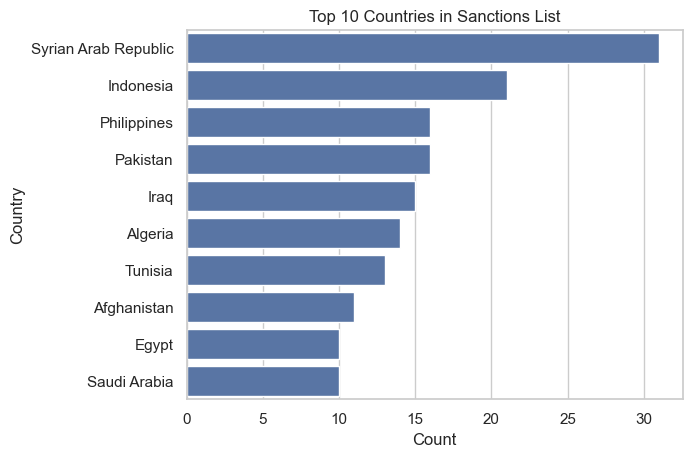

In [20]:
top_countries = final_df['country'].value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries in Sanctions List")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()

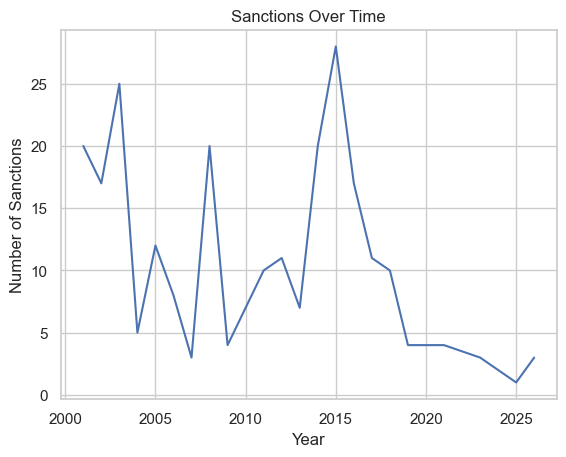

In [21]:
final_df['year'] = final_df['listed_on'].dt.year

year_counts = final_df['year'].value_counts().sort_index()

plt.plot(year_counts.index, year_counts.values)
plt.title("Sanctions Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Sanctions")
plt.show()

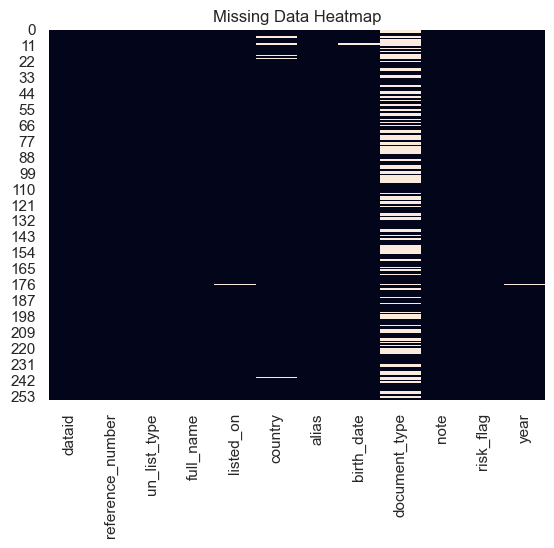

In [22]:
sns.heatmap(final_df.isnull(), cbar=False)
plt.title("Missing Data Heatmap")
plt.show()